# Step 1: Environment Setup and Dataset Loading

This cell handles the initialization of the Colab environment. It performs the following key operations:

1.  **Mounts Google Drive:** Connects to your Drive to access the dataset archive and provide a persistent location for saving model checkpoints and training logs.
2.  **Defines Directory Paths:** Sets up the necessary paths for both the local Colab runtime (for fast I/O) and Google Drive (for backup).
3.  **Data Transfer & Extraction:** Copies the `capsule.zip` dataset from Google Drive to the local Colab environment and extracts it.
    * *Note:* Transferring data to the local runtime is essential for training efficiency, as reading files directly from Drive can be significantly slower.

In [ ]:
import os
from google.colab import drive

# Mount Google Drive
print("Connecting to Google Drive...")
drive.mount('/content/drive')

# Define Project Paths
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/DGM_HW2"
os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)

DRIVE_ZIP_PATH = "/content/drive/MyDrive/capsule.zip"

# Path to save checkpoints and logs IN YOUR DRIVE
DRIVE_SAVE_DIR = os.path.join(DRIVE_PROJECT_DIR, "saved_models_maf_128")
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

COLAB_ZIP_PATH = "/content/capsule.zip"
COLAB_EXTRACT_DIR = "/content/capsule"
COLAB_TRAIN_DIR = "/content/capsule/train/good"

print(f"Google Drive mounted.")
print(f"Checkpoints will be saved to: {DRIVE_SAVE_DIR}")

# Copy and Unzip Dataset
try:
    if os.path.exists(COLAB_EXTRACT_DIR):
        print("Dataset already unzipped in Colab runtime.")
    else:
        print(f"Copying '{DRIVE_ZIP_PATH}' to Colab runtime...")
        os.system(f"cp '{DRIVE_ZIP_PATH}' {COLAB_ZIP_PATH}")

        print(f"Unzipping '{COLAB_ZIP_PATH}'...")
        os.system(f"unzip -q {COLAB_ZIP_PATH} -d {COLAB_EXTRACT_DIR}")
        print("Dataset copied and unzipped successfully.")

    if not os.path.exists(COLAB_TRAIN_DIR):
        print(f"Error: Directory not found at {COLAB_TRAIN_DIR}")
        print("Please check your zip file structure.")
    else:
        print("Data setup complete.")

except Exception as e:
    print(f"An error occurred during data setup: {e}")
    print("Please ensure the 'DRIVE_ZIP_PATH' is correct.")

Connecting to Google Drive...
Mounted at /content/drive
Google Drive mounted.
Checkpoints will be saved to: /content/drive/MyDrive/DGM_HW2/saved_models_maf_128
Copying '/content/drive/MyDrive/capsule.zip' to Colab runtime...
Unzipping '/content/capsule.zip'...
Dataset copied and unzipped successfully.
Data setup complete.


# Step 2: Model Architecture and Data Loading

This cell performs two critical tasks:

1.  **Data Loading:** Loads the training images from the local Colab environment using a custom `MVTecCapsuleDataset` class.
    * **Preprocessing:** Images are resized to 128x128.
    * **Dequantization:** Uniform noise is added to the discrete pixel values to convert them into a continuous distribution, which is a requirement for training normalizing flow models.

2.  **Model Definition:** Implements the Masked Autoregressive Flow (MAF) architecture.
    * **MaskedLinear:** A custom linear layer that applies binary masks to weights to enforce the autoregressive property.
    * **MADE Block:** Implements the Masked Autoencoder for Distribution Estimation using the `MaskedLinear` layers.
    * **MAF Model:** Stacks 7 MADE blocks. To improve expressivity, a random permutation of inputs is applied between consecutive blocks.
    * **Initialization:** Finally, the full model is initialized with the specified hyperparameters (D=49152, H=512) and moved to the GPU for training.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Define Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if "cuda" in device.type:
    !nvidia-smi -L

# Parameters
IMG_SIZE = 128
BATCH_SIZE = 2
IMG_CHANNELS = 3
D_FEATURES = IMG_SIZE * IMG_SIZE * IMG_CHANNELS # 49152
N_BLOCKS = 7
H = 512

print(f"Model parameters: D={D_FEATURES}, N_Blocks={N_BLOCKS}, H={H}")

# Data Loading
COLAB_TRAIN_DIR = "/content/capsule/train/good"

class MVTecCapsuleDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.png')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform: image = self.transform(image)
        image_tensor = transforms.ToTensor()(image)
        noise = torch.rand_like(image_tensor)
        image_dequantized = (image_tensor * 255.0 + noise) / 256.0
        return torch.clamp(image_dequantized, min=1e-5, max=1.0 - 1e-5)

data_transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE))])

try:
    full_train_dataset = MVTecCapsuleDataset(root_dir=COLAB_TRAIN_DIR, transform=data_transform)
    print(f"Loaded {len(full_train_dataset)} training images from Colab runtime.")
except Exception as e:
    print(f"Error loading dataset: {e}. (Did you run Cell 1 successfully?)")

# Model Definitions (MaskedLinear, MADE, MAF)
class MaskedLinear(nn.Linear):
    def __init__(self, in_features, out_features, bias=True):
        super(MaskedLinear, self).__init__(in_features, out_features, bias)
        self.register_buffer('mask', torch.ones(out_features, in_features))
    def set_mask(self, mask):
        self.mask.data.copy_(torch.from_numpy(mask.astype(np.uint8)))
    def forward(self, x):
        masked_weights = self.weight * self.mask
        return F.linear(x, masked_weights, self.bias)

class MADE(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super(MADE, self).__init__()
        self.in_features, self.hidden_features, self.out_features = in_features, hidden_features, out_features
        self.out_multiplier = 2
        self.layers = nn.ModuleList([
            MaskedLinear(self.in_features, hidden_features), nn.ReLU(),
            MaskedLinear(hidden_features, hidden_features), nn.ReLU(),
            MaskedLinear(hidden_features, self.out_features * self.out_multiplier)
        ])
        self.create_masks()
    def create_masks(self):
        m_in = torch.arange(self.in_features)
        m_out = torch.arange(self.out_features)
        m_hidden = torch.randint(0, self.in_features - 1, (self.hidden_features,))
        mask1 = (m_hidden.unsqueeze(1) >= m_in.unsqueeze(0)).float()
        mask2 = (m_hidden.unsqueeze(1) >= m_hidden.unsqueeze(0)).float()
        m_out_stacked = m_out.repeat(self.out_multiplier)
        mask3 = (m_out_stacked.unsqueeze(1) >= m_hidden.unsqueeze(0)).float()
        self.layers[0].set_mask(mask1.numpy())
        self.layers[2].set_mask(mask2.numpy())
        self.layers[4].set_mask(mask3.numpy())
    def forward(self, x):
        for layer in self.layers: x = layer(x)
        x = x.view(x.shape[0], self.out_features, self.out_multiplier)
        mu, log_std = x[..., 0], torch.tanh(x[..., 1]) * 3.0
        return mu, log_std

class MaskedAutoregressiveFlow(nn.Module):
    def __init__(self, n_blocks, in_features, hidden_features):
        super(MaskedAutoregressiveFlow, self).__init__()
        self.in_features = in_features
        self.base_dist = torch.distributions.Normal(torch.zeros(in_features).to(device), torch.ones(in_features).to(device))
        self.blocks = nn.ModuleList()
        self.permutations = []
        for i in range(n_blocks):
            self.blocks.append(MADE(in_features, hidden_features, in_features))
            p = torch.randperm(in_features, dtype=torch.int64).to(device)
            if i < n_blocks - 1: self.permutations.append(p)
    def forward(self, x):
        total_log_det_J = torch.zeros(x.shape[0]).to(device)
        z = x
        for i, block in enumerate(self.blocks):
            mu, log_std = block(z)
            std = torch.exp(log_std)
            z = (z - mu) / std
            log_det_J = -torch.sum(log_std, dim=1)
            total_log_det_J += log_det_J
            if i < len(self.permutations): z = z[:, self.permutations[i]]
        return z, total_log_det_J
    def inverse(self, z):
        x = torch.zeros_like(z)
        for i, block in reversed(list(enumerate(self.blocks))):
            if i < len(self.permutations): z = z[:, torch.argsort(self.permutations[i])]
            for dim in range(self.in_features):
                mu, log_std = block(x)
                std = torch.exp(log_std)
                x[:, dim] = z[:, dim] * std[:, dim] + mu[:, dim]
            z = x
        return x

# Initialize the Model
print("\nInitializing the 128x128 MAF model...")
model_maf = MaskedAutoregressiveFlow(N_BLOCKS, D_FEATURES, H).to(device)
print("Model initialized successfully and moved to GPU.")

Using device: cuda
GPU 0: Tesla T4 (UUID: GPU-8271d355-9f31-3fe8-600b-f78e9e69fa59)
Model parameters: D=49152, N_Blocks=7, H=512
Loaded 219 training images from Colab runtime.

Initializing the 128x128 MAF model... (This may take a moment)
Model initialized successfully and moved to GPU.


# Step 3: Training Loop

This is the core training cell. It handles the entire training process, including:

1.  **Hyperparameter Setup:** Defines training parameters like epochs (100), learning rate (0.0001), and checkpoint paths.
2.  **Model Initialization:** Sets up the optimizer (Adam) and learning rate scheduler (ReduceLROnPlateau).
3.  **Checkpoint Management:** Checks for existing checkpoints to resume training seamlessly if interrupted.
4.  **Data Splitting:** Creates a validation set (10% of training data) to monitor generalization and prevent overfitting.
5.  **Training Loop:** Iterates through epochs, performing forward/backward passes, calculating NLL loss, and updating model weights.
6.  **Validation & Saving:** Evaluates the model on the validation set after each epoch. It saves the **best model** (lowest validation loss) and periodically saves the **latest checkpoint** (every 15 epochs) to Google Drive for safety.

In [ ]:
import torch.optim as optim
from tqdm.notebook import tqdm
import time
import datetime
import json

# Training Configuration
N_EPOCHS = 100
LR = 0.0001
DRIVE_SAVE_DIR = "/content/drive/MyDrive/DGM_HW2/saved_models_maf_128"
CHECKPOINT_LATEST_FILE = os.path.join(DRIVE_SAVE_DIR, "maf_checkpoint_latest.pth")
CHECKPOINT_BEST_FILE = os.path.join(DRIVE_SAVE_DIR, "maf_checkpoint_best.pth")
HISTORY_FILE = os.path.join(DRIVE_SAVE_DIR, "maf_loss_history.json")

# Initialize Model, Optimizer, Scheduler
optimizer = optim.Adam(model_maf.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

# Checkpoint and History Initialization
start_epoch = 1
best_val_loss = float('inf')
train_loss_history = []
val_loss_history = []

# Load from Checkpoint (if it exists)
if os.path.exists(CHECKPOINT_LATEST_FILE):
    print(f"Loading 'latest' checkpoint from '{CHECKPOINT_LATEST_FILE}'...")
    try:
        checkpoint = torch.load(CHECKPOINT_LATEST_FILE)
        model_maf.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        print(f"Successfully loaded. Resuming training from Epoch {start_epoch}.")

    except Exception as e:
        print(f"Error loading checkpoint: {e}. Starting from scratch.")
else:
    print("No 'latest' checkpoint found. Starting training from scratch.")

# Load Loss History (if it exists)
if os.path.exists(HISTORY_FILE):
    print(f"Loading previous loss history from '{HISTORY_FILE}'...")
    try:
        with open(HISTORY_FILE, 'r') as f:
            hist_data = json.load(f)
            train_loss_history = hist_data.get('train_loss', [])[:start_epoch-1]
            val_loss_history = hist_data.get('val_loss', [])[:start_epoch-1]
        print(f"History loaded. Found {len(train_loss_history)} previous epochs.")
    except Exception as e:
        print(f"Error loading history: {e}. Starting with empty history.")
else:
    print("No loss history file found. Starting with empty history.")

print("\n--- Setup complete. Ready for training loop. ---")


# Create Validation Split
val_split = 0.1
dataset_size = len(full_train_dataset)
indices = list(range(dataset_size))
split_point = int(np.floor(val_split * dataset_size))
np.random.seed(42); np.random.shuffle(indices)
train_indices, val_indices = indices[split_point:], indices[:split_point]

train_sub_dataset = Subset(full_train_dataset, train_indices)
val_sub_dataset = Subset(full_train_dataset, val_indices)

train_loader_final = DataLoader(train_sub_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader_final = DataLoader(val_sub_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Data split complete: {len(train_sub_dataset)} train, {len(val_sub_dataset)} val.")

# Define Loss Function (NLL)
def calculate_nll(z, log_det_J):
    log_p_z = model_maf.base_dist.log_prob(z).sum(dim=1)
    log_p_x = log_p_z + log_det_J
    return -torch.mean(log_p_x)

print("Loss function (NLL) is defined.")

# The Final Training Loop
print(f"--- Starting Training from Epoch {start_epoch} to {N_EPOCHS} ---")
start_time = time.time()

for epoch in range(start_epoch, N_EPOCHS + 1):

    # (A) Training
    model_maf.train()
    train_loss_epoch = []
    progress_bar = tqdm(train_loader_final, desc=f"Epoch {epoch}/{N_EPOCHS} [Train]", leave=False)

    for batch in progress_bar:
        x = batch.to(device)
        x_flat = x.view(x.shape[0], -1)
        optimizer.zero_grad()
        z, log_det_J = model_maf.forward(x_flat)
        loss = calculate_nll(z, log_det_J)
        loss.backward()
        optimizer.step()
        train_loss_epoch.append(loss.item())
        progress_bar.set_postfix(NLL=loss.item())

    avg_train_loss = np.mean(train_loss_epoch)
    train_loss_history.append(avg_train_loss)

    # (B) Validation
    model_maf.eval()
    val_loss_epoch = []
    progress_bar_val = tqdm(val_loader_final, desc=f"Epoch {epoch}/{N_EPOCHS} [Val]", leave=False)
    with torch.no_grad():
        for batch in progress_bar_val:
            x = batch.to(device)
            x_flat = x.view(x.shape[0], -1)
            z, log_det_J = model_maf.forward(x_flat)
            loss = calculate_nll(z, log_det_J)
            val_loss_epoch.append(loss.item())
    avg_val_loss = np.mean(val_loss_epoch)
    val_loss_history.append(avg_val_loss)

    # (C) Scheduler and Checkpointing
    scheduler.step(avg_val_loss)

    # Check if this is the best model
    is_best_model = avg_val_loss < best_val_loss
    if is_best_model:
        best_val_loss = avg_val_loss

    # Save checkpoints to Drive every 15 epochs and in the last epoch
    #(I did not save the best model after each epoch, duo to memory constraints)
    if (epoch % 15 == 0) or (epoch == N_EPOCHS):

        print(f"--- Saving 'latest' checkpoint for epoch {epoch} to Google Drive ---")
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model_maf.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss': best_val_loss
        }
        torch.save(checkpoint, CHECKPOINT_LATEST_FILE)

        if is_best_model:
            print(f"*** This epoch ({epoch}) is the new BEST model. Saving to {CHECKPOINT_BEST_FILE} ***")
            torch.save(model_maf.state_dict(), CHECKPOINT_BEST_FILE)

    try:
        with open(HISTORY_FILE, 'w') as f:
            json.dump({'train_loss': train_loss_history, 'val_loss': val_loss_history}, f)
    except Exception as e:
        print(f"Warning: Could not save loss history to JSON. {e}")

    # (D) Print Epoch Summary
    print(f"Epoch {epoch}/{N_EPOCHS} Summary:")
    print(f"  Avg Train NLL: {avg_train_loss:.4f}")
    print(f"  Avg Val NLL:   {avg_val_loss:.4f}")
    print(f"  Best Val NLL:  {best_val_loss:.4f} {'(New Best!)' if is_best_model else ''}")
    print(f"  Current LR:    {optimizer.param_groups[0]['lr']:.6f}")

total_time = time.time() - start_time
print(f"--- Training Finished in {str(datetime.timedelta(seconds=total_time))} ---")

Loading 'latest' checkpoint from '/content/drive/MyDrive/DGM_HW2/saved_models_maf_128/maf_checkpoint_latest.pth'...
Error loading checkpoint: . Starting from scratch.
Loading previous loss history from '/content/drive/MyDrive/DGM_HW2/saved_models_maf_128/maf_loss_history.json'...
History loaded. Found 0 previous epochs.

--- Setup complete. Ready for training loop. ---
Data split complete: 198 train, 21 val.
Loss function (NLL) is defined.
--- Starting Training from Epoch 1 to 100 ---


Epoch 1/100 [Train]:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 1/100 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 1/100 Summary:
  Avg Train NLL: -43244.8611
  Avg Val NLL:   -101546.2962
  Best Val NLL:  -101546.2962 (New Best!)
  Current LR:    0.000100


Epoch 2/100 [Train]:   0%|          | 0/99 [00:00<?, ?it/s]

...

Epoch 99/100 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 99/100 Summary:
  Avg Train NLL: -176700.7868
  Avg Val NLL:   -173011.4361
  Best Val NLL:  -173870.5213 
  Current LR:    0.000100


Epoch 100/100 [Train]:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 100/100 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

--- Saving 'latest' checkpoint for epoch 100 to Google Drive ---
Epoch 100/100 Summary:
  Avg Train NLL: -177661.0156
  Avg Val NLL:   -172718.7713
  Best Val NLL:  -173870.5213 
  Current LR:    0.000100
--- Training Finished in 1:07:40.532150 ---


#loading the best model and generating 5 images without calculating generation time

# Step 4: Image Generation

This cell loads the best trained MAF model and generates new samples.

1.  **Initialization:** Clears GPU memory and sets up the model architecture with the same hyperparameters used during training ($128\times128$ input, 7 blocks, 512 hidden units).
2.  **Loading Weights:** Loads the model weights from the `maf_checkpoint_best.pth` file, ensuring the state dictionary keys match.
3.  **Sampling:** Generates 5 synthetic images by sampling latent vectors $z$ from a standard Gaussian distribution and passing them through the inverse flow ($x = f^{-1}(z)$). This step demonstrates the generative capability of the trained model.
4.  **Visualization:** Displays the generated samples after reshaping them to image format.

Cleaning up GPU memory...
GPU memory cleared. Ready for generation.
Loading BEST model from /content/drive/MyDrive/DGM_HW2/saved_models_maf_128/maf_checkpoint_best.pth...
Model loaded successfully.

Generating 5 samples (This will take a minute)...


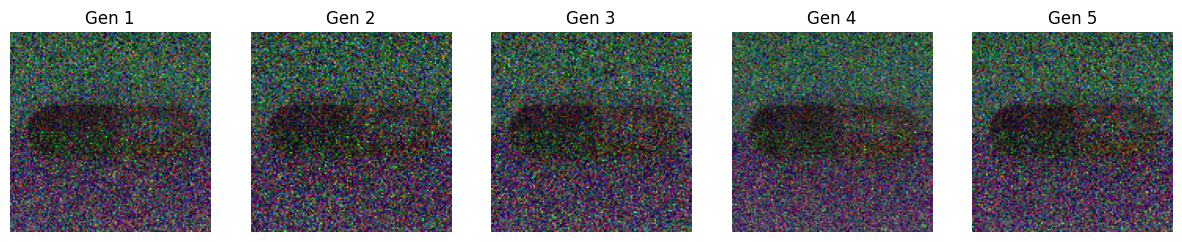

In [ ]:
import gc

# Clear GPU Memory
print(f"Cleaning up GPU memory...")

if 'model_maf' in locals(): del model_maf
if 'optimizer' in locals(): del optimizer
if 'scheduler' in locals(): del scheduler
if 'checkpoint' in locals(): del checkpoint

gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared. Ready for generation.")

# Configuration
DRIVE_SAVE_DIR = "/content/drive/MyDrive/DGM_HW2/saved_models_maf_128"
CHECKPOINT_BEST_FILE = os.path.join(DRIVE_SAVE_DIR, "maf_checkpoint_best.pth")

IMG_SIZE = 128
IMG_CHANNELS = 3
D_FEATURES = 128 * 128 * 3
N_BLOCKS = 7
H = 512
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-Define Model Classes
import torch.nn as nn
import torch.nn.functional as F

class MaskedLinear(nn.Linear):
    def __init__(self, in_features, out_features, bias=True):
        super(MaskedLinear, self).__init__(in_features, out_features, bias)
        self.register_buffer('mask', torch.ones(out_features, in_features))
    def set_mask(self, mask):
        self.mask.data.copy_(torch.from_numpy(mask.astype(np.uint8)))
    def forward(self, x):
        return F.linear(x, self.weight * self.mask, self.bias)

class MADE(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super(MADE, self).__init__()
        self.in_features, self.hidden_features, self.out_features = in_features, hidden_features, out_features
        self.out_multiplier = 2
        self.layers = nn.ModuleList([
            MaskedLinear(self.in_features, hidden_features), nn.ReLU(),
            MaskedLinear(hidden_features, hidden_features), nn.ReLU(),
            MaskedLinear(hidden_features, self.out_features * self.out_multiplier)
        ])
        self.create_masks()
    def create_masks(self):
        m_in, m_out = torch.arange(self.in_features), torch.arange(self.out_features)
        m_hidden = torch.randint(0, self.in_features - 1, (self.hidden_features,))
        mask1 = (m_hidden.unsqueeze(1) >= m_in.unsqueeze(0)).float()
        mask2 = (m_hidden.unsqueeze(1) >= m_hidden.unsqueeze(0)).float()
        mask3 = (m_out.repeat(self.out_multiplier).unsqueeze(1) >= m_hidden.unsqueeze(0)).float()
        self.layers[0].set_mask(mask1.numpy()); self.layers[2].set_mask(mask2.numpy()); self.layers[4].set_mask(mask3.numpy())
    def forward(self, x):
        for layer in self.layers: x = layer(x)
        x = x.view(x.shape[0], self.out_features, self.out_multiplier)
        return x[..., 0], torch.tanh(x[..., 1]) * 3.0

class MaskedAutoregressiveFlow(nn.Module):
    def __init__(self, n_blocks, in_features, hidden_features):
        super(MaskedAutoregressiveFlow, self).__init__()
        self.in_features = in_features
        self.base_dist = torch.distributions.Normal(torch.zeros(in_features).to(device), torch.ones(in_features).to(device))
        self.blocks = nn.ModuleList()
        self.permutations = []
        for i in range(n_blocks):
            self.blocks.append(MADE(in_features, hidden_features, in_features))
            if i < n_blocks - 1: self.permutations.append(torch.randperm(in_features, dtype=torch.int64).to(device))
    def inverse(self, z):
        x = torch.zeros_like(z)
        for i, block in reversed(list(enumerate(self.blocks))):
            if i < len(self.permutations): z = z[:, torch.argsort(self.permutations[i])]
            for dim in range(self.in_features):
                mu, log_std = block(x)
                x[:, dim] = z[:, dim] * torch.exp(log_std)[:, dim] + mu[:, dim]
            z = x
        return x

# Load BEST Model & Generate
print(f"Loading BEST model from {CHECKPOINT_BEST_FILE}...")
try:
    model_maf_eval = MaskedAutoregressiveFlow(N_BLOCKS, D_FEATURES, H).to(device)
    state_dict = torch.load(CHECKPOINT_BEST_FILE, map_location=device)

    if 'model_state_dict' in state_dict: model_maf_eval.load_state_dict(state_dict['model_state_dict'])
    else: model_maf_eval.load_state_dict(state_dict)

    model_maf_eval.eval()
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    raise

# Generate Samples
NUM_SAMPLES = 5
print(f"\nGenerating {NUM_SAMPLES} samples ...")

with torch.no_grad():
    z_samples = model_maf_eval.base_dist.sample((NUM_SAMPLES,))
    x_gen = model_maf_eval.inverse(z_samples)

# Visualize
x_gen = x_gen.view(NUM_SAMPLES, 3, IMG_SIZE, IMG_SIZE)
x_gen_cpu = x_gen.cpu().permute(0, 2, 3, 1).numpy()

plt.figure(figsize=(15, 4))
for i in range(NUM_SAMPLES):
    plt.subplot(1, NUM_SAMPLES, i + 1)
    img = np.clip(x_gen_cpu[i], 0, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Gen {i+1}")
plt.show()

#loading the best model and generating an image with calculating generation time

# Step 4(2)a: Environment Setup and Model Loading

In this cell, we prepare the environment for inference (image generation). The process involves several critical steps to ensure a clean and successful execution in a new Colab session:

1.  **Memory Cleanup:** We explicitly call garbage collection (`gc.collect()`) and empty the CUDA cache (`torch.cuda.empty_cache()`) to free up GPU memory from any previous operations, preventing Out-Of-Memory (OOM) errors.
2.  **Model Architecture Definition:** We must re-define the `MaskedLinear`, `MADE`, and `MaskedAutoregressiveFlow` classes. This is necessary because if the runtime is restarted, the class definitions are lost from memory, even if the model weights are saved on the disk.
3.  **Loading Weights:** We initialize the model architecture with the specific hyperparameters used during training ($128\times128$ input, 7 blocks, 512 hidden units) and then load the state dictionary from the `maf_checkpoint_best.pth` file.
4.  **Evaluation Mode:** Finally, `model.eval()` is called to switch the model to inference mode.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os
import gc
from google.colab import drive

# Cleanup memory just in case
gc.collect()
torch.cuda.empty_cache()

# Configuration
DRIVE_SAVE_DIR = "/content/drive/MyDrive/DGM_HW2/saved_models_maf_128"
CHECKPOINT_BEST_FILE = os.path.join(DRIVE_SAVE_DIR, "maf_checkpoint_best.pth")

IMG_SIZE = 128
IMG_CHANNELS = 3
D_FEATURES = 128 * 128 * 3
N_BLOCKS = 7
H = 512
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")

# Model Classes
class MaskedLinear(nn.Linear):
    def __init__(self, in_features, out_features, bias=True):
        super(MaskedLinear, self).__init__(in_features, out_features, bias)
        self.register_buffer('mask', torch.ones(out_features, in_features))
    def set_mask(self, mask):
        self.mask.data.copy_(torch.from_numpy(mask.astype(np.uint8)))
    def forward(self, x):
        return F.linear(x, self.weight * self.mask, self.bias)

class MADE(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super(MADE, self).__init__()
        self.in_features, self.hidden_features, self.out_features = in_features, hidden_features, out_features
        self.out_multiplier = 2
        self.layers = nn.ModuleList([
            MaskedLinear(self.in_features, hidden_features), nn.ReLU(),
            MaskedLinear(hidden_features, hidden_features), nn.ReLU(),
            MaskedLinear(hidden_features, self.out_features * self.out_multiplier)
        ])
        self.create_masks()
    def create_masks(self):
        m_in, m_out = torch.arange(self.in_features), torch.arange(self.out_features)
        m_hidden = torch.randint(0, self.in_features - 1, (self.hidden_features,))
        mask1 = (m_hidden.unsqueeze(1) >= m_in.unsqueeze(0)).float()
        mask2 = (m_hidden.unsqueeze(1) >= m_hidden.unsqueeze(0)).float()
        mask3 = (m_out.repeat(self.out_multiplier).unsqueeze(1) >= m_hidden.unsqueeze(0)).float()
        self.layers[0].set_mask(mask1.numpy()); self.layers[2].set_mask(mask2.numpy()); self.layers[4].set_mask(mask3.numpy())
    def forward(self, x):
        for layer in self.layers: x = layer(x)
        x = x.view(x.shape[0], self.out_features, self.out_multiplier)
        return x[..., 0], torch.tanh(x[..., 1]) * 3.0

class MaskedAutoregressiveFlow(nn.Module):
    def __init__(self, n_blocks, in_features, hidden_features):
        super(MaskedAutoregressiveFlow, self).__init__()
        self.in_features = in_features
        self.base_dist = torch.distributions.Normal(torch.zeros(in_features).to(device), torch.ones(in_features).to(device))
        self.blocks = nn.ModuleList()
        self.permutations = []
        for i in range(n_blocks):
            self.blocks.append(MADE(in_features, hidden_features, in_features))
            if i < n_blocks - 1: self.permutations.append(torch.randperm(in_features, dtype=torch.int64).to(device))
    def inverse(self, z):
        x = torch.zeros_like(z)
        for i, block in reversed(list(enumerate(self.blocks))):
            if i < len(self.permutations): z = z[:, torch.argsort(self.permutations[i])]
            for dim in range(self.in_features):
                mu, log_std = block(x)
                x[:, dim] = z[:, dim] * torch.exp(log_std)[:, dim] + mu[:, dim]
            z = x
        return x

# Load Weights
print(f"Loading BEST model from {CHECKPOINT_BEST_FILE}...")
try:
    model_maf_eval = MaskedAutoregressiveFlow(N_BLOCKS, D_FEATURES, H).to(device)
    state_dict = torch.load(CHECKPOINT_BEST_FILE, map_location=device)
    if 'model_state_dict' in state_dict:
        model_maf_eval.load_state_dict(state_dict['model_state_dict'])
    else:
        model_maf_eval.load_state_dict(state_dict)

    model_maf_eval.eval()
    print("Model loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}")

Device: cuda
Loading BEST model from /content/drive/MyDrive/DGM_HW2/saved_models_maf_128/maf_checkpoint_best.pth...
Model loaded successfully!


# Step 4(2)b: Single Image Generation and Timing Analysis

This cell is designed to generate a single sample from the trained MAF model and measure the precise time required for this process. This is crucial for analyzing the computational cost of autoregressive models.

**The Process:**
1.  **Latent Sampling:** A latent vector $z$ is sampled from the base distribution (Standard Normal).
2.  **Inverse Pass (Generation):** The model performs the inverse transformation $x = f^{-1}(z)$. This step is computationally expensive and sequential, as each pixel $x_i$ is generated based on the previously generated pixels $x_{1:i-1}$.
3.  **Timing:** We use `time.time()` and a manual `tqdm` progress bar to track exactly how long the inverse pass takes. This duration will be reported and compared against training times in the final report.
4.  **Visualization:** The generated tensor is reshaped into image dimensions ($3 \times 128 \times 128$), permuted to HWC format, clipped to the valid $[0, 1]$ range, and displayed.


Generating 1 sample...


Generating Image:   0%|          | 0/1 [00:00<?, ?it/s]

----------------------------------------
Image Generated Successfully!
Time Taken: 1711.7539 seconds
----------------------------------------


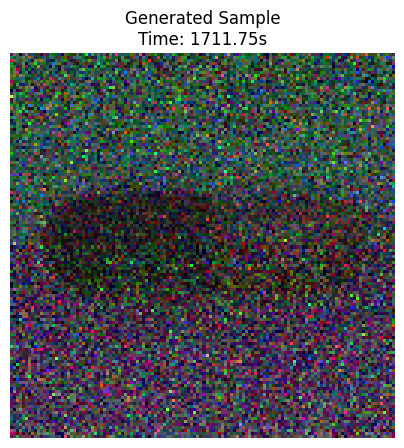

In [ ]:
import time
from tqdm.notebook import tqdm

# Generate 1 Sample
print("\nGenerating 1 sample...")

start_time = time.time()

with tqdm(total=1, desc="Generating Image") as pbar:
    with torch.no_grad():
        z_sample = model_maf_eval.base_dist.sample((1,))

        x_gen = model_maf_eval.inverse(z_sample)

    pbar.update(1)

end_time = time.time()
duration = end_time - start_time

# Report & Visualize
print("-" * 40)
print(f"Image Generated Successfully!")
print(f"Time Taken: {duration:.4f} seconds")
print("-" * 40)

# Visualize
x_gen_img = x_gen.view(3, IMG_SIZE, IMG_SIZE).cpu().permute(1, 2, 0).numpy()
img = np.clip(x_gen_img, 0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off')
plt.title(f"Generated Sample\nTime: {duration:.2f}s")
plt.show()

# Step 5a: Anomaly Detection Setup

This cell prepares the environment for the anomaly detection task.

1.  **Drive & Config:** Mounts Google Drive and sets up paths to the saved best model and the test dataset.
2.  **Test Dataset Class:** Defines `MVTecTestDataset`, a custom dataset class designed to parse the MVTec AD folder structure (separating 'good' images from anomaly classes like 'crack', 'squeeze', etc.) and assign labels (0 for normal, 1 for anomaly).
3.  **Model Definition:** Re-defines the MAF architecture classes (`MaskedLinear`, `MADE`, `MaskedAutoregressiveFlow`) to ensure the model structure is available in memory.
4.  **Model Loading:** Loads the weights from `maf_checkpoint_best.pth` and sets the model to evaluation mode (`eval()`).
5.  **Data Loader:** Creates a DataLoader for the test set.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os
from google.colab import drive
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm.notebook import tqdm
from PIL import Image

# Configuration & Mount
if not os.path.exists('/content/drive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

DRIVE_SAVE_DIR = "/content/drive/MyDrive/DGM_HW2/saved_models_maf_128"
CHECKPOINT_BEST_FILE = os.path.join(DRIVE_SAVE_DIR, "maf_checkpoint_best.pth")

TEST_PATH_1 = "/content/capsule/test"
TEST_PATH_2 = "/content/capsule/capsule/test"
COLAB_TEST_DIR = TEST_PATH_2 if os.path.exists(TEST_PATH_2) else TEST_PATH_1

IMG_SIZE = 128
IMG_CHANNELS = 3
D_FEATURES = 128 * 128 * 3
N_BLOCKS = 7
H = 512
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
print(f"Test Data Path: {COLAB_TEST_DIR}")

# Define Test Dataset Class
class MVTecTestDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = [] # 0 for 'good', 1 for 'anomaly'

        if os.path.exists(root_dir):
            for class_name in os.listdir(root_dir):
                class_dir = os.path.join(root_dir, class_name)
                if not os.path.isdir(class_dir): continue

                label = 0 if class_name == 'good' else 1

                for img_name in os.listdir(class_dir):
                    if img_name.endswith('.png'):
                        self.image_paths.append(os.path.join(class_dir, img_name))
                        self.labels.append(label)
        else:
            print(f"Error: Test directory not found at {root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        image_tensor = transforms.ToTensor()(image)
        return image_tensor, label

# Re-Define Model Classes
class MaskedLinear(nn.Linear):
    def __init__(self, in_features, out_features, bias=True):
        super(MaskedLinear, self).__init__(in_features, out_features, bias)
        self.register_buffer('mask', torch.ones(out_features, in_features))
    def set_mask(self, mask):
        self.mask.data.copy_(torch.from_numpy(mask.astype(np.uint8)))
    def forward(self, x):
        return F.linear(x, self.weight * self.mask, self.bias)

class MADE(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super(MADE, self).__init__()
        self.in_features, self.hidden_features, self.out_features = in_features, hidden_features, out_features
        self.out_multiplier = 2
        self.layers = nn.ModuleList([
            MaskedLinear(self.in_features, hidden_features), nn.ReLU(),
            MaskedLinear(hidden_features, hidden_features), nn.ReLU(),
            MaskedLinear(hidden_features, self.out_features * self.out_multiplier)
        ])
        self.create_masks()
    def create_masks(self):
        m_in, m_out = torch.arange(self.in_features), torch.arange(self.out_features)
        m_hidden = torch.randint(0, self.in_features - 1, (self.hidden_features,))
        mask1 = (m_hidden.unsqueeze(1) >= m_in.unsqueeze(0)).float()
        mask2 = (m_hidden.unsqueeze(1) >= m_hidden.unsqueeze(0)).float()
        mask3 = (m_out.repeat(self.out_multiplier).unsqueeze(1) >= m_hidden.unsqueeze(0)).float()
        self.layers[0].set_mask(mask1.numpy()); self.layers[2].set_mask(mask2.numpy()); self.layers[4].set_mask(mask3.numpy())
    def forward(self, x):
        for layer in self.layers: x = layer(x)
        x = x.view(x.shape[0], self.out_features, self.out_multiplier)
        return x[..., 0], torch.tanh(x[..., 1]) * 3.0

class MaskedAutoregressiveFlow(nn.Module):
    def __init__(self, n_blocks, in_features, hidden_features):
        super(MaskedAutoregressiveFlow, self).__init__()
        self.in_features = in_features
        self.base_dist = torch.distributions.Normal(torch.zeros(in_features).to(device), torch.ones(in_features).to(device))
        self.blocks = nn.ModuleList()
        self.permutations = []
        for i in range(n_blocks):
            self.blocks.append(MADE(in_features, hidden_features, in_features))
            if i < n_blocks - 1: self.permutations.append(torch.randperm(in_features, dtype=torch.int64).to(device))
    def inverse(self, z):
        return z
    def forward(self, x):
        total_log_det_J = torch.zeros(x.shape[0]).to(device)
        z = x
        for i, block in enumerate(self.blocks):
            mu, log_std = block(z)
            std = torch.exp(log_std)
            z = (z - mu) / std
            log_det_J = -torch.sum(log_std, dim=1)
            total_log_det_J += log_det_J
            if i < len(self.permutations): z = z[:, self.permutations[i]]
        return z, total_log_det_J

# Load Data & Model
test_transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE))])
test_dataset = MVTecTestDataset(COLAB_TEST_DIR, transform=test_transform)

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Test dataset loaded: {len(test_dataset)} images.")

print(f"Loading BEST model from {CHECKPOINT_BEST_FILE}...")
try:
    model_maf_eval = MaskedAutoregressiveFlow(N_BLOCKS, D_FEATURES, H).to(device)
    state_dict = torch.load(CHECKPOINT_BEST_FILE, map_location=device)
    if 'model_state_dict' in state_dict: model_maf_eval.load_state_dict(state_dict['model_state_dict'])
    else: model_maf_eval.load_state_dict(state_dict)
    model_maf_eval.eval()
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")

Device: cuda
Test Data Path: /content/capsule/test
Test dataset loaded: 132 images.
Loading BEST model from /content/drive/MyDrive/DGM_HW2/saved_models_maf_128/maf_checkpoint_best.pth...
Model loaded successfully.


# Step 5b: Evaluation and Metric Calculation (AUROC)

This cell performs the actual anomaly detection and performance evaluation.

1.  **Scoring:** It iterates through the test dataset. For each image, it computes the **Negative Log-Likelihood (NLL)** using the trained MAF model. Since the model was trained on normal data, high NLL values indicate a low probability of the sample belonging to the normal distribution, thus serving as an **Anomaly Score**.
2.  **AUROC Calculation:** Using the computed anomaly scores and the ground truth labels, it calculates the **Area Under the ROC Curve (AUROC)**, which is the standard metric for evaluating anomaly detection performance.
3.  **Visualization:**
    * **Histogram:** Plots the distribution of anomaly scores for normal vs. anomalous images to visualize separability.
    * **ROC Curve:** Plots the True Positive Rate vs. False Positive Rate at various thresholds.

Calculating Anomaly Scores (NLL)...


  0%|          | 0/9 [00:00<?, ?it/s]


>>> AUROC Score: 0.7036 <<<


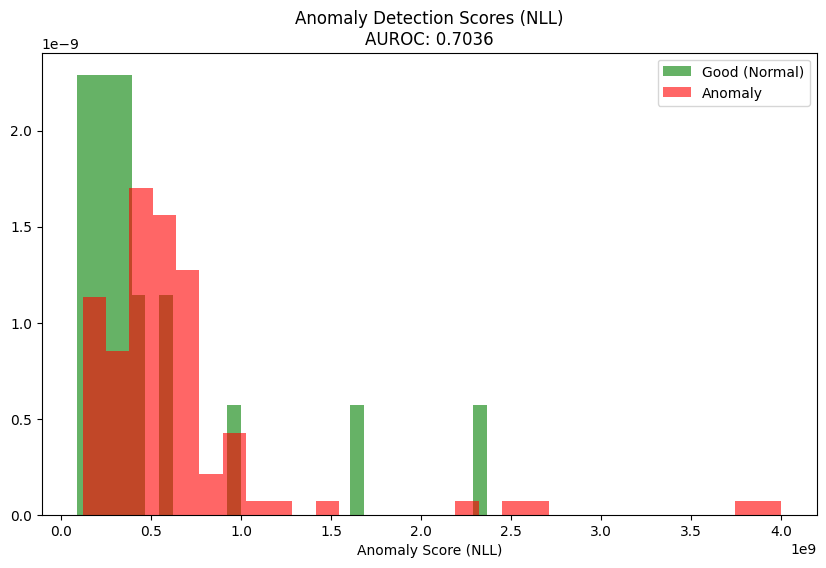

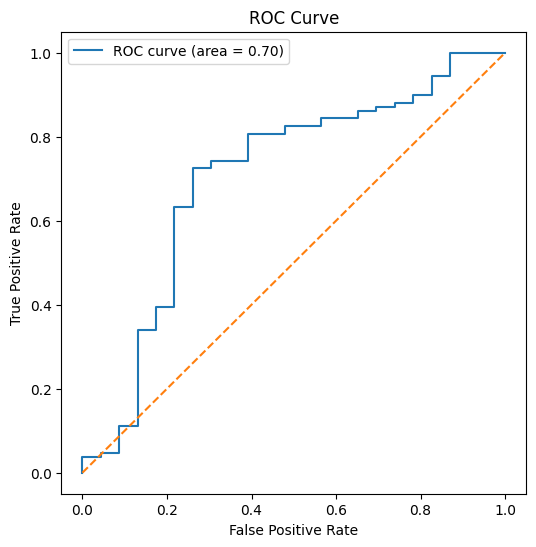

In [ ]:
# Evaluation Loop
nll_scores = []
true_labels = []

print("Calculating Anomaly Scores (NLL)...")

with torch.no_grad():
    for x, label in tqdm(test_loader):
        x = x.to(device)
        x_flat = x.view(x.shape[0], -1)

        # Forward pass
        z, log_det_J = model_maf_eval(x_flat)

        # Calculate log_p(x)
        log_p_z = model_maf_eval.base_dist.log_prob(z).sum(dim=1)
        log_p_x = log_p_z + log_det_J

        # Anomaly Score = Negative Log Likelihood
        nll = -log_p_x

        nll_scores.extend(nll.cpu().numpy())
        true_labels.extend(label.numpy())

# Calculate AUROC & Plot
if len(set(true_labels)) > 1:
    auroc = roc_auc_score(true_labels, nll_scores)
    print(f"\n>>> AUROC Score: {auroc:.4f} <<<")

    # Plot Histogram
    scores_good = [s for s, l in zip(nll_scores, true_labels) if l == 0]
    scores_anomaly = [s for s, l in zip(nll_scores, true_labels) if l == 1]

    plt.figure(figsize=(10, 6))
    plt.hist(scores_good, bins=30, alpha=0.6, label='Good (Normal)', color='green', density=True)
    plt.hist(scores_anomaly, bins=30, alpha=0.6, label='Anomaly', color='red', density=True)
    plt.title(f"Anomaly Detection Scores (NLL)\nAUROC: {auroc:.4f}")
    plt.xlabel("Anomaly Score (NLL)")
    plt.legend()
    plt.show()

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(true_labels, nll_scores)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {auroc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()
else:
    print("Error: Test set must contain both normal and anomaly images.")